_Imports_

In [1]:
import os
import torch
import imageio
import subprocess
import numpy as np
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.spatial import cKDTree
import plotly.graph_objects as go
from IPython.display import Image as IPImage

_Paths_

In [2]:
input_dir = Path("/kaggle/input")
working_dir = Path("/kaggle/working")
images_dir = input_dir / "datasets" / "naginagiyev03" / "3d-images2"
scene_dir = working_dir / "scene"
sparse_dir = scene_dir / "sparse"
database_path = scene_dir / "database.db"
init_gaussians_path = scene_dir / "gaussians_init.pt"
trained_gaussians_path = scene_dir / "gaussians_trained.pt"
gif_path = scene_dir / "spin.gif"
ply_path = scene_dir / "minifig.ply"

In [3]:
# makes sure that COLMAP does not uses the screen 
# because there's not a screen in kaggle
os.environ["QT_QPA_PLATFORM"] = "offscreen"

In [4]:
# create a workspace folder
!mkdir -p {scene_dir}

# install colmap
!apt-get update -qq && apt-get install -y colmap

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas libamd2 libatk-bridge2.0-0
  libatk1.0-0 libatk1.0-data libatspi2.0-0 libcamd2 libccolamd2 libceres2
  libcholmod3 libcolamd2 libcxsparse3 libdouble-conversion3 libevdev2
  libfreeimage3 libgflags2.2 libglew2.2 libgoogle-glog0v5 libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libinput-bin libinput10 libmd4c0
  libmetis5 libmtdev1 libqt5core5a libqt5dbus5 libqt5gui5 libqt5network5
  libqt5svg5 libqt5widgets5 libraw20 libspqr2 libsuitesparseconfig5
  libwacom-bin libwacom-common libwacom9 libxcb-icccm4 libxcb-image0
  libxcb-keysyms1 libxcb-render-util0 libxcb-util1 libxcb-xinerama0
  libxcb-xinput0 libxcb

In [5]:
# 1. takes the images from folder
# 2. finds distinct points in every photo (points that are recognozible
#    by computer from different angles)
# 3. stores these features in an sql-lite database

# everything runs on cpu and...
# this command assumes that all photos have been shot from one single camera

!colmap feature_extractor \
    --database_path {database_path} \
    --image_path {images_dir} \
    --ImageReader.camera_model SIMPLE_RADIAL \
    --ImageReader.single_camera 1 \
    --SiftExtraction.use_gpu 0


Feature extraction

Processed file [1/75]
  Name:            IMG_20260926_125744.jpg
  Dimensions:      1944 x 1944
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    2721.60px (Prior)
  Features:        1045
Processed file [2/75]
  Name:            IMG_20260926_125731.jpg
  Dimensions:      1944 x 1944
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    2721.60px (Prior)
  Features:        1594
Processed file [3/75]
  Name:            IMG_20260926_125814.jpg
  Dimensions:      1944 x 1944
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    2721.60px (Prior)
  Features:        1301
Processed file [4/75]
  Name:            IMG_20260926_125737.jpg
  Dimensions:      1944 x 1944
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    2721.60px (Prior)
  Features:        1124
Processed file [5/75]
  Name:            IMG_20260926_125818.jpg
  Dimensions:      1944 x 1944
  Camera:          #1 - SIMPLE_RADIAL
  Focal Length:    2721.60px (Prior)
  Features:        1088
Proc

In [6]:
# compare every photo against every other photo and find which photos are matching
# in other words compare points and link them as same pyhsical points from different angles

# max_error = 6 - means max allowed error between specific points of compared images is 6 pixels
# min_num_inliers = 10 - when comparing 2 photos, if the number of matched points...
#                        is less than 10, then both photos are not accepted as related

!colmap exhaustive_matcher \
    --database_path {database_path} \
    --SiftMatching.use_gpu 0 \
    --SiftMatching.max_error 6 \
    --SiftMatching.min_num_inliers 10


Exhaustive feature matching

Matching block [1/2, 1/2] in 106.891s
Matching block [1/2, 2/2] in 28.666s
Matching block [2/2, 1/2] in 79.381s
Matching block [2/2, 2/2] in 25.997s
Elapsed time: 4.016 [minutes]


In [7]:
!mkdir -p {sparse_dir}

# this algorithm is called "Incremental Structure-from-Motion (SfM)"
# it first picks 2 strong canditate as starting pair and then...
# it finds other strong canditates against what is already built
# it is repeated one photo at a time and in every step the algorithm...
# globally refine the positions to minimize overall error 
!colmap mapper \
    --database_path {database_path} \
    --image_path {images_dir} \
    --output_path {sparse_dir}


Loading database

Loading cameras... 1 in 0.000s
Loading matches... 1013 in 0.006s
Loading images... 75 in 0.015s (connected 74)
Building correspondence graph... in 0.015s (ignored 567)

Elapsed time: 0.001 [minutes]


Finding good initial image pair


Initializing with image pair #8 and #68


Global bundle adjustment

iter      cost      cost_change  |gradient|   |step|    tr_ratio  tr_radius  ls_iter  iter_time  total_time
   0  2.798774e+02    0.00e+00    5.97e+04   0.00e+00   0.00e+00  1.00e+04        0    6.84e-04    1.87e-03
   1  1.464921e+02    1.33e+02    4.47e+04   2.87e+00   9.13e-01  2.28e+04        1    1.30e-03    3.20e-03
   2  1.041470e+02    4.23e+01    5.38e+04   4.97e+01   9.03e-01  4.80e+04        1    9.89e-04    4.21e-03
   3  9.591335e+01    8.23e+00    3.44e+04   5.41e+01   8.82e-01  8.68e+04        1    9.84e-04    5.21e-03
   4  9.450738e+01    1.41e+00    8.82e+03   3.13e+01   9.18e-01  2.08e+05        1    9.57e-04    6.19e-03
   5  9.434743e+01    1.60e-01

In [8]:
# sometimes colmap can not connect all of the photos into one 3D reconstruction
# it creates several separate numbered folders
# this code finds which of these folders are the best one (the one that we'll use)
# it looks inside all folders, convert them into a readable text format,...
# count how many photos in each txt and select the best of them

best_path, best_count = None, -1

for folder in sorted(sparse_dir.iterdir()):
    if not folder.is_dir() or not folder.name.isdigit():
        continue
    txt_path = sparse_dir / f"{folder.name}_txt"
    txt_path.mkdir(exist_ok=True)
    subprocess.run(["colmap", "model_converter", "--input_path", str(folder),
                     "--output_path", str(txt_path), "--output_type", "TXT"])
    with open(txt_path / "images.txt") as f:
        count = sum(1 for line in f
                    if line.strip() and not line.startswith("#") and line.split()[0].isdigit())
    if count > best_count:
        best_count, best_path = count, txt_path

print(best_path, best_count)

/kaggle/working/scene/sparse/0_txt 32


In [26]:
# the code shows extracted points on a 3D environment
# lists stores points and their colors
points, colors = [], []
with open(best_path / "points3D.txt") as f:
    for line in f:
        # skip comments/headers of colmap and empty lines
        if line.startswith("#") or not line.strip():
            continue
        parts = line.split()
        # append the position in 3D space
        points.append([float(parts[1]), float(parts[2]), float(parts[3])])
        # append the color
        colors.append(f"rgb({parts[4]},{parts[5]},{parts[6]})")

points = np.array(points)

# display the points
fig = go.Figure(data=[go.Scatter3d(x=points[:, 0], y=points[:, 1], z=points[:, 2], mode="markers",
                                   marker=dict(size=2, color=colors))])
fig.update_layout(scene=dict(aspectmode="data"), margin=dict(l=0, r=0, t=0, b=0))
fig.show()

In [10]:
# this function reads images.txt and stores the important details inside it on a dictionary to use later
# image.txt contains information that tells us from where each photo has been taken from
def read_images_txt(path):
    images = {}
    with open(path) as f:
        lines = [line for line in f if line.strip() and not line.startswith("#")]
    for i in range(0, len(lines), 2):
        parts = lines[i].split()
        image_id = int(parts[0])
        quaternion = np.array(list(map(float, parts[1:5])))
        translation = np.array(list(map(float, parts[5:8])))
        camera_id = int(parts[8])
        name = parts[9]
        images[image_id] = dict(quaternion=quaternion, translation=translation,
                                camera_id=camera_id, name=name)
    return images

# this file describes the lens
# it contains one line per physical camera
# as we have used only one camera, this file is one line in total
def read_cameras_txt(path):
    cameras = {}
    with open(path) as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            parts = line.split()
            camera_id = int(parts[0])
            cameras[camera_id] = dict(model=parts[1], width=int(parts[2]), height=int(parts[3]),
                                      params=list(map(float, parts[4:])))
    return cameras

images = read_images_txt(best_path / "images.txt")
cameras = read_cameras_txt(best_path / "cameras.txt")

In [11]:
# functions reads 3D point's positions and color as we used before
# it makes it easy to call and use the txt file later on the code
def read_points3d_txt(path):
    xyz, rgb = [], []
    with open(path) as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            parts = line.split()
            xyz.append([float(parts[1]), float(parts[2]), float(parts[3])])
            rgb.append([int(parts[4]), int(parts[5]), int(parts[6])])
    return np.array(xyz), np.array(rgb)

xyz_array, rgb_array = read_points3d_txt(best_path / "points3D.txt")

In [12]:
# this code creates actual gaussians
# it turns each dot in 3D we saw, into fuzzy blob with a size, orientation, transparency and color

# a KD-Tree tells us what is the closest point to a given point
tree = cKDTree(xyz_array)
# k=2: index 0 is itself, index 1 is nearest other point
distances, _ = tree.query(xyz_array, k=2)
nearest_distances = np.clip(distances[:, 1], 1e-7, None)

xyz = torch.tensor(xyz_array, dtype=torch.float32, requires_grad=True)

# size - starts ~= gap to nearest neighbor (sparse areas get bigger blobs)
scales = torch.tensor(np.log(nearest_distances), dtype=torch.float32)
scales = scales.unsqueeze(1).repeat(1, 3).requires_grad_(True)
# rotation - starts as "no rotation"
rotations = torch.zeros(len(xyz_array), 4)
rotations[:, 0] = 1.0
rotations.requires_grad_(True)
# opacity - starts 10% solid, avoids one blob dominating early
opacities = torch.full((len(xyz_array), 1), -2.1972, requires_grad=True)
# color - convert 0-255 rgb into spherical harmonics DC term format
sh_dc = torch.tensor((rgb_array / 255.0 - 0.5) / 0.28209479177387814, dtype=torch.float32,
                     requires_grad=True)
# bundle all trainable params together for easy saving/looping
gaussians = dict(xyz=xyz, scales=scales, rotations=rotations, opacities=opacities, sh_dc=sh_dc)

In [13]:
# save a checkpoint of the initialized gaussians
torch.save({k: v.detach() for k, v in gaussians.items()}, init_gaussians_path)

In [14]:
# convert quaternion numbers into 3x3 rotation matrix 
def quaternion_to_matrix(quaternion):
    w, x, y, z = quaternion
    return np.array([
        [1-2*(y**2+z**2), 2*(x*y-z*w), 2*(x*z+y*w)],
        [2*(x*y+z*w), 1-2*(x**2+z**2), 2*(y*z-x*w)],
        [2*(x*z-y*w), 2*(y*z+x*w), 1-2*(x**2+y**2)]
    ])

# the function returns everything we need for rendering for a specific photo
def get_camera(image_id):
    image = images[image_id]
    camera_rotation = torch.tensor(quaternion_to_matrix(image["quaternion"]), dtype=torch.float32)
    camera_translation = torch.tensor(image["translation"], dtype=torch.float32)
    camera = cameras[image["camera_id"]]
    focal, center_x, center_y = camera["params"][0], camera["params"][1], camera["params"][2]
    return (camera_rotation, camera_translation, focal, center_x, center_y,
            camera["width"], camera["height"])

In [15]:
# converts quaternions into 3x3 rotation matrix 
# uses pytorch in order to convert all at once, not one by one
def build_rotation(quaternions):
    quaternions = quaternions / quaternions.norm(dim=-1, keepdim=True)
    w, x, y, z = quaternions.unbind(-1)
    rotation_matrix = torch.stack([
        1-2*(y**2+z**2), 2*(x*y-z*w), 2*(x*z+y*w),
        2*(x*y+z*w), 1-2*(x**2+z**2), 2*(y*z-x*w),
        2*(x*z-y*w), 2*(y*z+x*w), 1-2*(x**2+y**2)
    ], dim=-1).reshape(-1, 3, 3)
    return rotation_matrix

# scales and rotate into one shape matrix per gaussian
def build_covariance3d(scales, rotations):
    scale_matrix = torch.diag_embed(torch.exp(scales)) # stretch step
    rotation_matrix = build_rotation(rotations) # rotation
    # @ means matrix multiplication
    # combines stretch and rotation into one matrix
    transform = rotation_matrix @ scale_matrix
    return transform @ transform.transpose(1, 2)

In [16]:
# this is a rasterizer
# it takes a 3D gaussian and completes a complete 2D image in 5 steps
# 1. move blobs into camera's point of view
# 2. flatten each blob's position onto the 2D photo
# 3. flatten each blob's shape onto the 2D photo too
# 4. measure how far every pixel is from every blob's center
# 5. blend all the overlapping blobs together correctly

def render(xyz, scales, rotations, opacities, sh_dc, camera_rotation, camera_translation,
           focal, center_x, center_y, width, height):
    # 1. move blobs into camera's point of view
    device = xyz.device
    camera_xyz = xyz @ camera_rotation.T + camera_translation
    depth = camera_xyz[:, 2]
    valid = depth > 0.2
    camera_xyz, depth = camera_xyz[valid], depth[valid]

    # 2. flatten each blob's position onto the 2D photo
    mean2d = torch.stack([focal * camera_xyz[:, 0] / depth + center_x,
                          focal * camera_xyz[:, 1] / depth + center_y], dim=1)

    # 3. flatten each blob's shape onto the 2D photo too
    covariance3d = build_covariance3d(scales[valid], rotations[valid])
    camera_covariance = camera_rotation.unsqueeze(0) @ covariance3d @ camera_rotation.T.unsqueeze(0)

    jacobian = torch.zeros(depth.shape[0], 2, 3, device=device)
    jacobian[:, 0, 0] = focal / depth
    jacobian[:, 0, 2] = -focal * camera_xyz[:, 0] / depth**2
    jacobian[:, 1, 1] = focal / depth
    jacobian[:, 1, 2] = -focal * camera_xyz[:, 1] / depth**2

    covariance2d = jacobian @ camera_covariance @ jacobian.transpose(1, 2)
    covariance2d[:, 0, 0] += 0.3
    covariance2d[:, 1, 1] += 0.3
    inverse_covariance2d = torch.linalg.inv(covariance2d)

    # 4. measure how far every pixel is from every blob's center
    ys, xs = torch.meshgrid(torch.arange(height, dtype=torch.float32, device=device),
                            torch.arange(width, dtype=torch.float32, device=device), indexing="ij")
    pixels = torch.stack([xs, ys], dim=-1).reshape(-1, 2)

    offsets = pixels.unsqueeze(0) - mean2d.unsqueeze(1)
    weighted_offsets = torch.einsum("nij,npj->npi", inverse_covariance2d, offsets)
    power = -0.5 * torch.einsum("npi,npi->np", offsets, weighted_offsets)

    # 5. blend all the overlapping blobs together correctly
    alpha = torch.sigmoid(opacities[valid]) * torch.exp(power.clamp(max=0))
    alpha = alpha.clamp(0, 0.99)

    order = torch.argsort(depth)
    alpha = alpha[order]
    colors = (0.28209479177387814 * sh_dc[valid][order] + 0.5).clamp(0, 1)

    transmittance = torch.cumprod(1 - alpha, dim=0)
    shifted_transmittance = torch.cat([torch.ones(1, alpha.shape[1], device=device),
                                       transmittance[:-1]], dim=0)
    weight = alpha * shifted_transmittance

    # sum everything into one final image
    image = torch.einsum("np,nc->pc", weight, colors)
    return image.reshape(height, width, 3).clamp(0, 1)

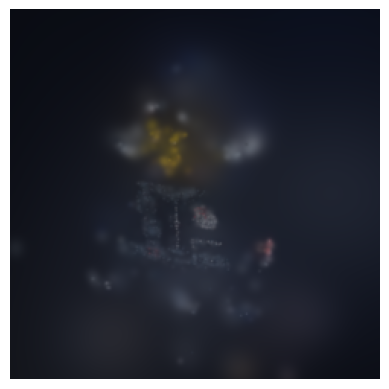

In [17]:
# this code renders your gaussians into an actual image and displays it
image_id = list(images.keys())[0]
camera_rotation, camera_translation, focal, center_x, center_y, width, height = get_camera(image_id)

scale = 8
render_width, render_height = width // scale, height // scale
render_focal, render_center_x, render_center_y = focal / scale, center_x / scale, center_y / scale

with torch.no_grad():
    output = render(xyz, scales, rotations, opacities, sh_dc, camera_rotation, camera_translation,
                    render_focal, render_center_x, render_center_y, render_width, render_height)

plt.imshow(output.numpy())
plt.axis("off")
plt.show()

In [18]:
# this code moves all your trainable gaussian tensors into the GPU
device = "cuda" if torch.cuda.is_available() else "cpu"

xyz = xyz.detach().to(device).requires_grad_(True)
scales = scales.detach().to(device).requires_grad_(True)
rotations = rotations.detach().to(device).requires_grad_(True)
opacities = opacities.detach().to(device).requires_grad_(True)
sh_dc = sh_dc.detach().to(device).requires_grad_(True)

In [19]:
# define optimizer
# we define different learning rates for each type of optimizer
optimizer = torch.optim.Adam([
    {"params": [xyz], "lr": 0.001},
    {"params": [scales], "lr": 0.005},
    {"params": [rotations], "lr": 0.001},
    {"params": [opacities], "lr": 0.05},
    {"params": [sh_dc], "lr": 0.0025},
])

In [20]:
# this code loads a real photo based on its id and...
# prepares it to be compared to the rendered result
def load_target(image_id, render_width, render_height, device):
    name = images[image_id]["name"]
    image = Image.open(images_dir / name).convert("RGB").resize((render_width, render_height))
    image_array = np.array(image, dtype=np.float32) / 255.0
    return torch.tensor(image_array, device=device)

In [21]:
# training loop
num_iterations = 2500
image_ids = list(images.keys())

progress_bar = tqdm(range(num_iterations))
for _ in progress_bar:
    # 1. pick a random real photo
    image_id = image_ids[np.random.randint(len(image_ids))]
    camera_rotation, camera_translation, focal, center_x, center_y, width, height = get_camera(image_id)
    camera_rotation, camera_translation = camera_rotation.to(device), camera_translation.to(device)
    render_focal, render_center_x, render_center_y = focal / scale, center_x / scale, center_y / scale
    render_width, render_height = width // scale, height // scale

    target = load_target(image_id, render_width, render_height, device)
    # 2. render the gaussians from the same angle
    output = render(xyz, scales, rotations, opacities, sh_dc, camera_rotation, camera_translation,
                    render_focal, render_center_x, render_center_y, render_width, render_height)

    # 3. measure how different the render is from real photo
    loss = F.l1_loss(output, target)
    optimizer.zero_grad()
    
    # 4. change gaussian property to close the gap
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        opacities.clamp_(-10, 10)

    progress_bar.set_description(f"loss {loss.item():.4f}")

  0%|          | 0/2500 [00:00<?, ?it/s]

In [22]:
# save trained gaussians
trained_gaussians = dict(xyz=xyz, scales=scales, rotations=rotations, opacities=opacities,
                         sh_dc=sh_dc)
torch.save({k: v.detach().cpu() for k, v in trained_gaussians.items()}, trained_gaussians_path)

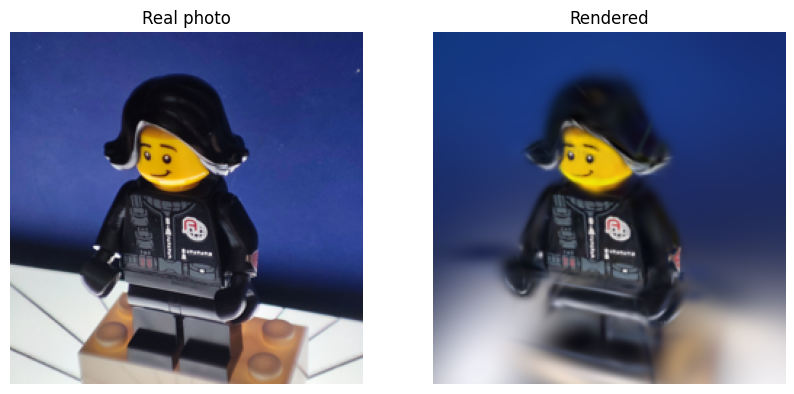

In [23]:
# this code loads trained checkpoints and render one view from your trained gaussians
# in other words, it renders the image from a specific view (2D, not 3D)
checkpoint = torch.load(trained_gaussians_path)
trained_xyz = checkpoint["xyz"].to(device)
trained_scales = checkpoint["scales"].to(device)
trained_rotations = checkpoint["rotations"].to(device)
trained_opacities = checkpoint["opacities"].to(device)
trained_sh_dc = checkpoint["sh_dc"].to(device)

image_id = image_ids[0]
camera_rotation, camera_translation, focal, center_x, center_y, width, height = get_camera(image_id)
camera_rotation, camera_translation = camera_rotation.to(device), camera_translation.to(device)
render_focal, render_center_x, render_center_y = focal / scale, center_x / scale, center_y / scale
render_width, render_height = width // scale, height // scale

with torch.no_grad():
    output = render(trained_xyz, trained_scales, trained_rotations, trained_opacities,
                    trained_sh_dc, camera_rotation, camera_translation, render_focal,
                    render_center_x, render_center_y, render_width, render_height)

target = load_target(image_id, render_width, render_height, device)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(target.cpu().numpy()); axes[0].set_title("Real photo"); axes[0].axis("off")
axes[1].imshow(output.cpu().numpy()); axes[1].set_title("Rendered"); axes[1].axis("off")
plt.show()

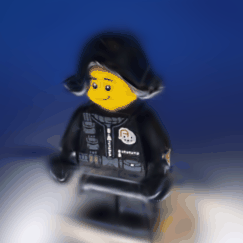

In [24]:
# renders trained gaussians from every angle and...
# converts all those individual renders together into an animated GIF
frames = []
with torch.no_grad():
    for image_id in image_ids:
        camera_rotation, camera_translation, focal, center_x, center_y, width, height = get_camera(image_id)
        camera_rotation, camera_translation = camera_rotation.to(device), camera_translation.to(device)
        render_focal, render_center_x, render_center_y = focal / scale, center_x / scale, center_y / scale
        render_width, render_height = width // scale, height // scale
        frame = render(trained_xyz, trained_scales, trained_rotations, trained_opacities,
                       trained_sh_dc, camera_rotation, camera_translation, render_focal,
                       render_center_x, render_center_y, render_width, render_height)
        frames.append((frame.clamp(0, 1).cpu().numpy() * 255).astype("uint8"))

imageio.mimsave(gif_path, frames, duration=0.3)
IPImage(str(gif_path))

In [25]:
# this function converts trained gaussians into a .ply file (a standard 3D file format)
# you can view it by uploading the .ply file into a web-based splat viewer (e.g https://superspl.at/editor)
def export_ply(xyz, scales, rotations, opacities, sh_dc, path, sh_degree=3):
    xyz = xyz.detach().cpu().numpy()
    scales = scales.detach().cpu().numpy()
    rotations = rotations.detach().cpu().numpy()
    rotations = rotations / np.linalg.norm(rotations, axis=1, keepdims=True)
    opacities = opacities.detach().cpu().numpy()
    sh_dc = sh_dc.detach().cpu().numpy()
    num_gaussians = xyz.shape[0]
    num_rest = 3 * ((sh_degree + 1) ** 2 - 1)

    dtype = [("x", "f4"), ("y", "f4"), ("z", "f4"), ("nx", "f4"), ("ny", "f4"), ("nz", "f4"),
             ("f_dc_0", "f4"), ("f_dc_1", "f4"), ("f_dc_2", "f4")]
    dtype += [(f"f_rest_{i}", "f4") for i in range(num_rest)]
    dtype += [("opacity", "f4"), ("scale_0", "f4"), ("scale_1", "f4"), ("scale_2", "f4"),
              ("rot_0", "f4"), ("rot_1", "f4"), ("rot_2", "f4"), ("rot_3", "f4")]

    elements = np.zeros(num_gaussians, dtype=dtype)
    elements["x"], elements["y"], elements["z"] = xyz[:, 0], xyz[:, 1], xyz[:, 2]
    elements["f_dc_0"], elements["f_dc_1"], elements["f_dc_2"] = sh_dc[:, 0], sh_dc[:, 1], sh_dc[:, 2]
    elements["opacity"] = opacities[:, 0]
    elements["scale_0"], elements["scale_1"], elements["scale_2"] = scales[:, 0], scales[:, 1], scales[:, 2]
    elements["rot_0"], elements["rot_1"] = rotations[:, 0], rotations[:, 1]
    elements["rot_2"], elements["rot_3"] = rotations[:, 2], rotations[:, 3]

    with open(path, "wb") as f:
        header = f"ply\nformat binary_little_endian 1.0\nelement vertex {num_gaussians}\n"
        for name, _ in dtype:
            header += f"property float {name}\n"
        header += "end_header\n"
        f.write(header.encode())
        f.write(elements.tobytes())

export_ply(xyz, scales, rotations, opacities, sh_dc, ply_path)